In [1]:
%load_ext autoreload
%autoreload 2

/tmp/dgodi_3883152_hyd/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Converting to graphs:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1736083029558/work/aten/src/ATen/native/TensorShape.cpp:3683.)
  g.y = t.T  # (n_wt,)
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /hom

generated 4 graphs from 4 cases


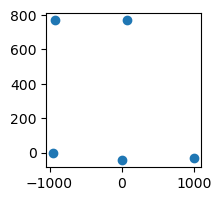

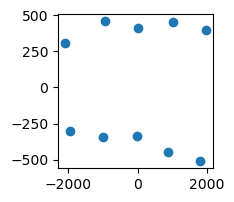

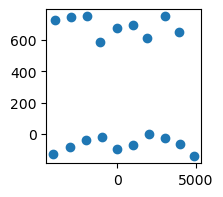

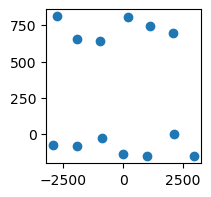

Data(
  pos=[13, 2],
  edge_index=[2, 58],
  edge_attr=[58, 2],
  x=[13, 4],
  y=[13],
  globals=[2],
  meta={
    layout_id='0000003',
    connectivity='delaunay',
    per_turbine_features=True,
    yaws_method='COBYQA-QMCB',
    info=[3],
    wd_deg=270.0,
    ws=6.0,
    ti=0.05000000074505806,
    farm_center_x=2890.737858063367,
    farm_center_y=50.226387758069905,
  },
  name='0000003_delaunay_1.00_COBYQA-QMCB_('0000003', '13', 'test')_270.00_6.00_0.05_2890.74_50.23'
)


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib widget
# import matplotlib.pyplot as plt

# import os
# os.environ.pop("MPLBACKEND", None)  # remove Agg if set
# import matplotlib
# matplotlib.use("module://matplotlib_inline.backend_inline")

from utils.to_graph import test_cases_graph

wd_ = 270
graphs, layouts, inflows = test_cases_graph(wd_=wd_)
for name, g in graphs.items():
    plt.figure(figsize=(2, 2))
    plt.scatter(g.pos[:, 0], g.pos[:, 1])
    plt.show()
print(g)

In [3]:
# ensure rotation works correctly

In [4]:
from utils.to_graph import rotate_to_west_centered, unrotate_from_west_centered

for (name, g), layout, inflow in zip(graphs.items(), layouts, inflows):
    assert np.allclose(
        unrotate_from_west_centered(
            g.pos, wd_deg=wd_, center=(g.meta["farm_center_x"], g.meta["farm_center_y"])
        ),
        layout["coords"],
        atol=1e-4,  # minor numerical errors with rotation
    ), "g.pos dont match graph to layout"
    assert np.allclose(g.globals[0], inflow["WS"]), "g.globals no match to inflow"

In [5]:
from utils.to_graph import graph_maker_sequential, graph_maker_lut
from itertools import product

# check test_cases_graph.generate_graphs
graphs, layouts, inflows = test_cases_graph()
# for name, g in graphs.items():
#     print(f"Graph {name}:")
#     print(g)
#     print("meta:", g.meta)
# check rotated graphs
wd_ = 188.0
graphs, layouts, inflows = test_cases_graph(wd_=wd_)
for (name, g), layout, inflow in zip(graphs.items(), layouts, inflows):
    assert np.allclose(
        unrotate_from_west_centered(
            g.pos,
            wd_deg=wd_,
            center=(g.meta["farm_center_x"], g.meta["farm_center_y"]),
        ),
        layout["coords"],
        atol=1e-3,
    ), "g.pos dont match graph to layout"
    assert np.allclose(g.globals[0], inflow["WS"]), "g.globals no match to inflow"

# check graph_maker_sequential
# match test_cases_graph first and compare
graphs, layouts, inflows = test_cases_graph(wd_=wd_)
wd_ = inflows[0]["WD"]
xs = [l["coords"][:, 0] for l in layouts]
ys = [l["coords"][:, 1] for l in layouts]
n_layouts = len(xs)
graphs = graph_maker_sequential(
    xs=xs,
    ys=ys,
    wds=[wd_] * n_layouts,
    wss=[inflows[0]["WS"]] * n_layouts,
    TIs=[inflows[0]["TI"]] * n_layouts,
)
for (name, g), layout, inflow in zip(graphs.items(), layouts, inflows):
    assert np.allclose(
        unrotate_from_west_centered(
            g.pos,
            wd_deg=wd_,
            center=(g.meta["farm_center_x"], g.meta["farm_center_y"]),
        ),
        layout["coords"],
        atol=1e-3,
    ), "g.pos dont match graph to layout"
    assert np.allclose(g.globals[0], inflow["WS"]), "g.globals no match to inflow"

Converting to graphs:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1736083029558/work/aten/src/ATen/native/TensorShape.cpp:3683.)
  g.y = t.T  # (n_wt,)
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /hom

generated 4 graphs from 4 cases



Converting to graphs:   0%|          | 0/4 [00:00<?, ?it/s]

...

generated 4 graphs from 4 cases





Converting to graphs:   0%|          | 0/4 [00:04<?, ?it/s]


  0%|          | 0/4 [00:00<?, ?it/s]

generated 4 graphs from 4 cases


/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1736083029558/work/aten/src/ATen/native/TensorShape.cpp:3683.)
  g.y = t.T  # (n_wt,)
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /hom

In [6]:
# unr = unrotate_from_west_centered(
#     g.pos,
#     wd_deg=inflow['WD'],
#     center=(g.meta["farm_center_x"], g.meta["farm_center_y"]),
# ).round(4)
# unr

# ll = layout_.round(4)
# ll

# len(wss)*len(wds)#/batch_size

In [7]:
# check graph_maker_lut
wds = np.arange(0, 360, 2)
wss = np.arange(3, 25, 1)
ti = inflows[2]["TI"]
n_wt = len(xs[2])
graphs = graph_maker_lut(
    x=xs[2],
    y=ys[2],
    wds=wds,
    wss=wss,
    TI=ti,
)
inflows = [
    {"WS": float(ws), "TI": float(ti), "WD": float(wd)} for wd, ws in product(wds, wss)
]
layout_ = np.column_stack((xs[2], ys[2]))

for (name, g), inflow in zip(graphs.items(), inflows):
    assert np.allclose(
        unrotate_from_west_centered(
            g.pos,
            wd_deg=inflow["WD"],
            center=(g.meta["farm_center_x"], g.meta["farm_center_y"]),
        ),
        layout_,
        atol=1e-3,
    ), "g.pos dont match graph to layout"
    assert np.allclose(g.globals[0], inflow["WS"]), "g.globals no match to inflow"

Converting to graphs:   0%|          | 0/3960 [00:00<?, ?it/s]

  0%|          | 0/3960 [00:00<?, ?it/s]

/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1736083029558/work/aten/src/ATen/native/TensorShape.cpp:3683.)
  g.y = t.T  # (n_wt,)
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/to_graph.py:244: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /hom

generated 3960 graphs from 3960 cases


In [9]:
from utils.pred import predict

model_path = "models/best.pt"
results = predict(
    model_path=model_path,
    test_graphs=graphs,  # GraphSet
    batch_size=len(wds),
    reshape=(n_wt, len(wds), len(wss))
)

# batched_results -> results as if batch_size=1
# results = [row for row in np.concatenate([np.atleast_2d(r) for r in results], axis=0)]

/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

Number of trainable parameters: 1450241
Evaluating model models/best.pt


In [10]:
# # batch_size = 1
# I = len(results[0])  # turbines
# L = len(wds)  # wind directions
# K = len(wss)  # wind speeds

# arr = np.stack(results, axis=0)  # (L*K, I)
# arr_LKI = arr.reshape(L, K, I)  # (L, K, I)  WD-major, WS-minor
# arr_ILK = np.transpose(arr_LKI, (2, 0, 1))  # (I, L, K)  <-- PyWake ILK

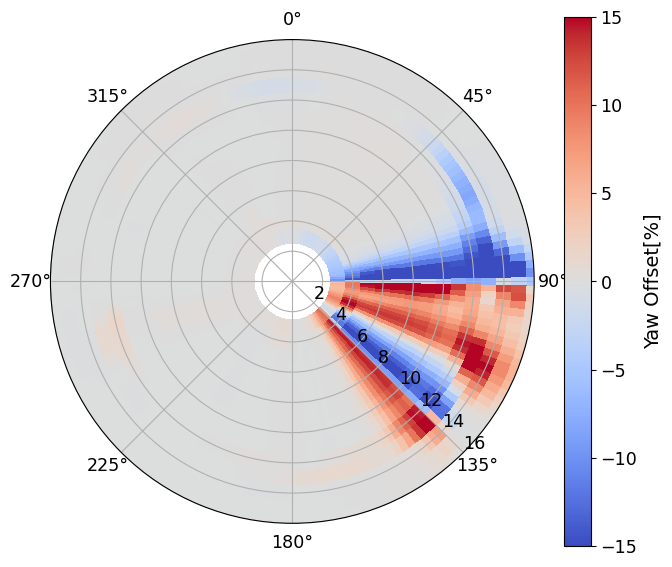

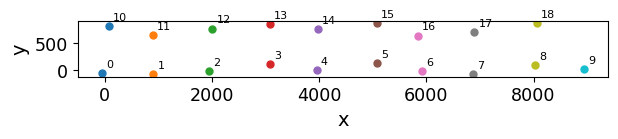

Converting to graphs:   0%|          | 0/3960 [00:11<?, ?it/s]


57326.810268917536
57577.72166312242
0.43768595013026523


In [11]:
from utils.plot_utils import lut_heatmap, lut_3d_heatmap

lut_3d_heatmap(results[9, :, :], wds=wds, wss=wss)  # turbine 0

x = layout_[:, 0]
y = layout_[:, 1]

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(str(i), (xi, yi), xytext=(3, 3), textcoords="offset points",
                 ha="left", va="bottom", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()


from py_wake import HorizontalGrid
from utils.get_flowmodel import get_flowmodel
from utils.iea22s import IEA22s

wt = IEA22s()
wf_model = get_flowmodel(wt=wt)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=ti, yaw=0, tilt=0)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=ti, yaw=results, tilt=0)

uni_aep_base=sim_base.aep().sum().values
print(uni_aep_base)
uni_aep_gnn=sim_gnn.aep().sum().values
print(uni_aep_gnn)
print(100*(uni_aep_gnn-uni_aep_base)/uni_aep_base)

In [12]:
# from utils.plot_utils import pretty_flowmap

# n_ws = len(wss)
# figs = []
# for wd_idx, wd_ in enumerate(wds):
#     for ws_idx, ws_ in enumerate(wss):
#         if ws_ != 5:
#             continue
#         grph = graphs[wd_idx * n_ws + ws_idx]  # pick matching graph
#         yaw_set = results[:, wd_idx, ws_idx]  # (n_wt,)

#         ti_ = grph.globals[0][1]
#         x_, y_ = layout_[:, 0], layout_[:, 1]

#         sim_base = wf_model(x=x_, y=y_, wd=wd_, ws=ws_, TI=ti_, yaw=0, tilt=0)
#         sim_gnn = wf_model(x=x_, y=y_, wd=wd_, ws=ws_, TI=ti_, yaw=yaw_set, tilt=0)

#         fmap_base = sim_base.flow_map(grid=HorizontalGrid(resolution=150, extend=0.5))
#         fmap_gnn = sim_gnn.flow_map(grid=HorizontalGrid(resolution=150, extend=0.5))

#         ws_diff = fmap_gnn.WS_eff.squeeze() - fmap_base.WS_eff.squeeze()
#         base_power = (sim_base.Power.sum() / 1e6).round(2).item()
#         gnn_power = (sim_gnn.Power.sum() / 1e6).round(2).item()
#         uplift = np.round(100 * (gnn_power - base_power) / base_power, 2)
#         fig, ax = pretty_flowmap(
#             ws_diff,
#             x_,
#             y_,
#             yaw_set,
#             yaw_deg=yaw_set,
#             wd_deg=wd_,
#             D=284,
#             title=f"WS={ws_}, WD={wd_}, Uplift={uplift}%",
#             clim=(-1.5, 1.5),
#             show=False,
#         )
#         figs.append(fig)
#         print(f"Power uplift:{uplift}%\nbase:{base_power}, gnn:{gnn_power}")

In [13]:
# from utils.anim_utils import save_mp4_from_figs

# video_path = save_mp4_from_figs(
#     figs, "flowmaptt.mp4", fps=2, dpi=120, target_size=(1280, 720)
# )
# print("saved:", video_path)

In [14]:
# %conda install -y -c conda-forge ffmpeg
# !ffmpeg -version

In [15]:
from utils.sites import Hornsrev1Site
from utils.easy import easy_yaw_gnn

wds = np.arange(0, 360, 2)
wss = np.arange(3, 18, 1)
TI = 0.06
(x, y), site = Hornsrev1Site(scale_D=wt.diameter())
yaws = easy_yaw_gnn(x, y, wd=wds, ws=wss, TI=TI)

Converting to graphs:   0%|          | 0/2700 [00:00<?, ?it/s]

  0%|          | 0/2700 [00:00<?, ?it/s]

generated 2700 graphs from 2700 cases
Number of trainable parameters: 1450241
Evaluating model models/best.pt


/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

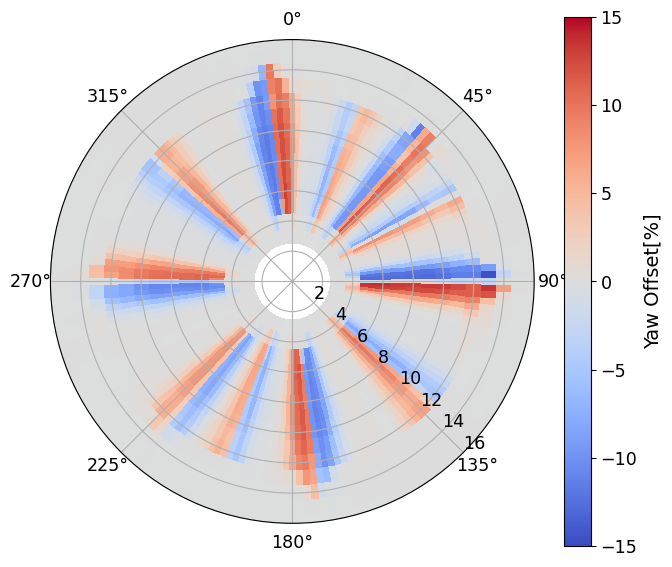

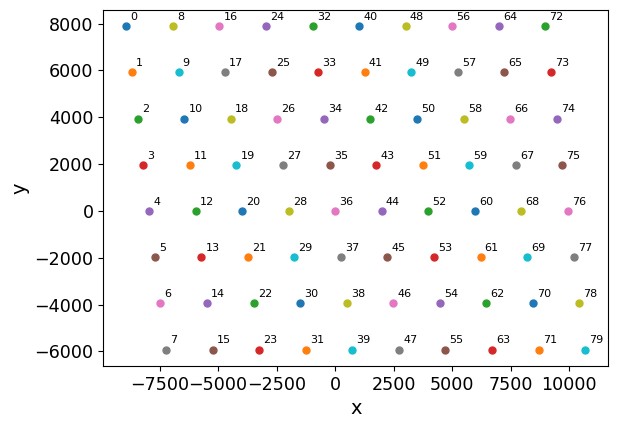

7868.5961197431625
7928.597390242371
0.7625409868052441


In [16]:
from utils.plot_utils import lut_3d_heatmap

lut_3d_heatmap(yaws[66, :, :], wds=wds, wss=wss)  # turbine 0

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=8,
    )

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=0, tilt=0, n_cpu=16)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=yaws, tilt=0, n_cpu=16)

uni_aep_base = sim_base.aep().sum().values
print(uni_aep_base)
uni_aep_gnn = sim_gnn.aep().sum().values
print(uni_aep_gnn)
print(100 * (uni_aep_gnn - uni_aep_base) / uni_aep_base)

In [17]:
wds_sub = np.arange(0, 70, 2)
wss_sub = np.arange(5, 10, 2)
yaws = easy_yaw_gnn(x, y, wd=wds_sub, ws=wss_sub, TI=TI)

sim_base = wf_model(x=x, y=y, wd=wds_sub, ws=wss_sub, TI=TI, yaw=0, tilt=0, n_cpu=16)
sim_gnn = wf_model(x=x, y=y, wd=wds_sub, ws=wss_sub, TI=TI, yaw=yaws, tilt=0, n_cpu=16)

fmap_base = sim_base.flow_map(grid=HorizontalGrid(resolution=100, extend=0.1))
fmap_gnn = sim_gnn.flow_map(grid=HorizontalGrid(resolution=100, extend=0.1))

Converting to graphs:   0%|          | 0/105 [00:00<?, ?it/s]

  0%|          | 0/105 [00:00<?, ?it/s]

Converting to graphs:   0%|          | 0/105 [00:00<?, ?it/s]

generated 105 graphs from 105 cases
Number of trainable parameters: 1450241
Evaluating model models/best.pt



/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torc

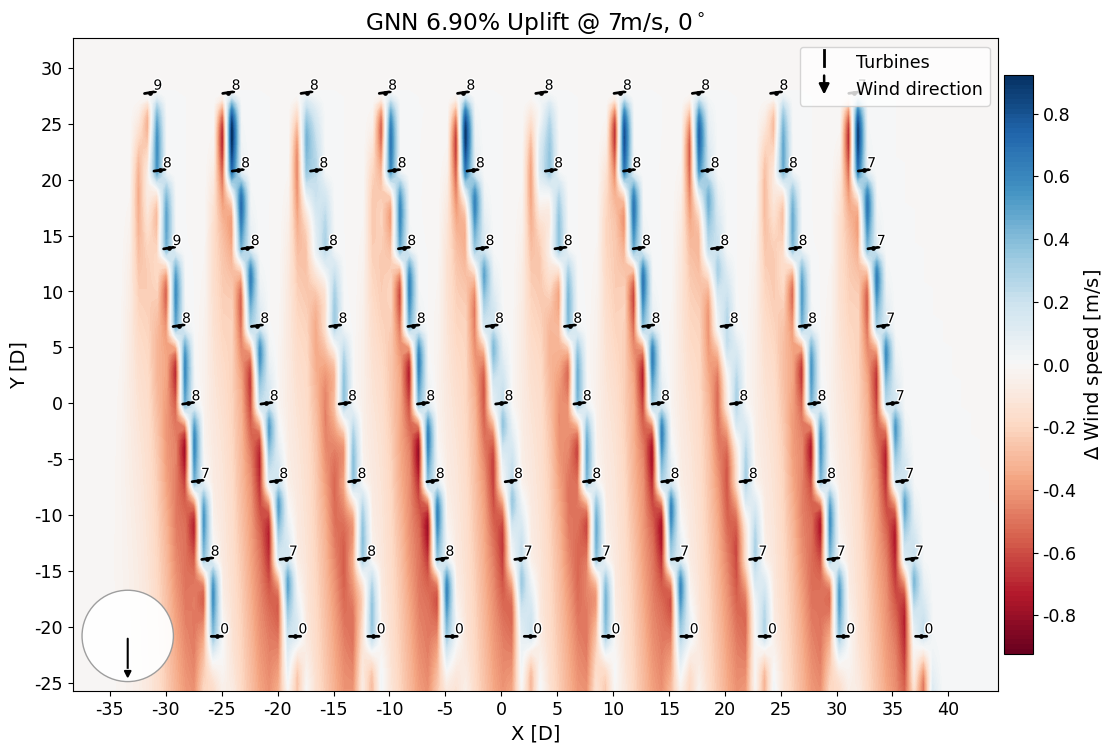

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'GNN 6.90% Uplift @ 7m/s, 0$^\\circ$'}, xlabel='X [D]', ylabel='Y [D]'>)

In [18]:
from utils.plot_utils import pretty_flowmap

wd_ = 0
ws_ = 7

base_power = float(sim_base.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
gnn_power = float(sim_gnn.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
denom = base_power if base_power != 0.0 else np.finfo(float).eps
uplift = round(100 * (gnn_power - base_power) / denom, 2)

ws_base = fmap_base.WS_eff.sel(wd=wd_, ws=ws_).squeeze()
ws_gnn = fmap_gnn.WS_eff.sel(wd=wd_, ws=ws_).squeeze()
ws_diff = ws_gnn - ws_base

yaw_set = yaws[:, 0, 2]  # 0 deg, 7m/s
D = 284
pretty_flowmap(
    ws_diff,
    x,
    y,
    yaw_set,  # pts to show
    yaw_deg=yaw_set,
    wd_deg=wd_,
    D=D,
    title=fr"GNN {uplift:.2f}% Uplift @ {ws_}m/s, {wd_}$^\circ$",
    clim=None,
    show=True,
    fsize=(12, 12)
)

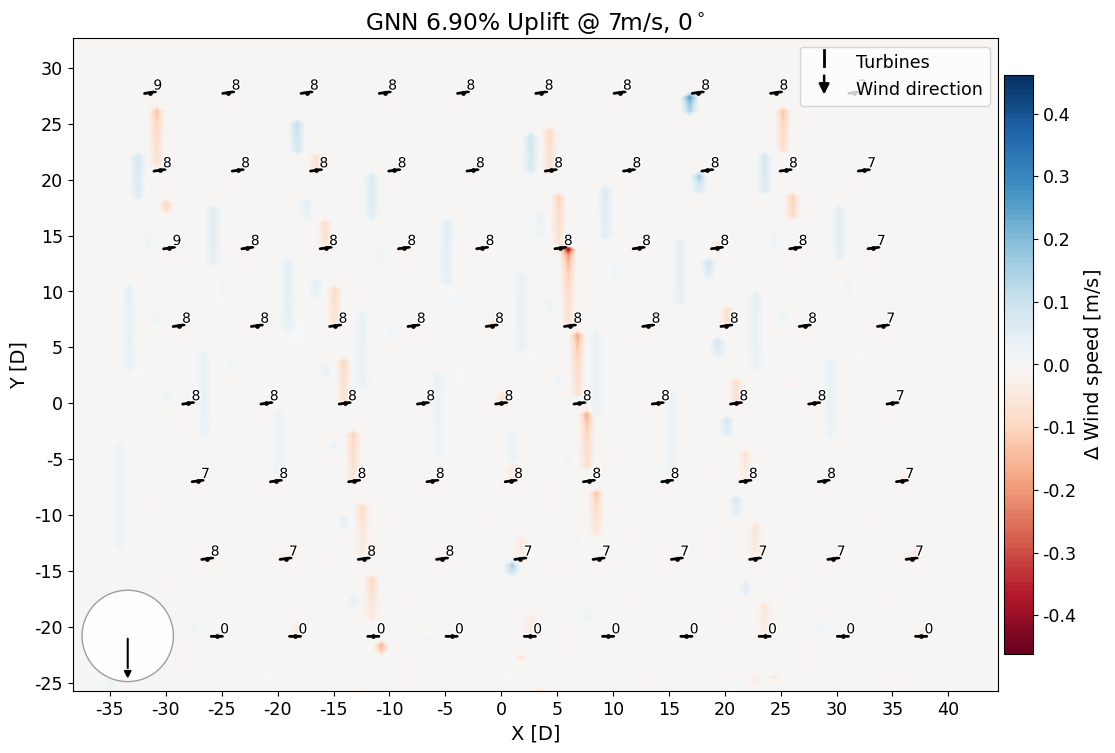

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'GNN 6.90% Uplift @ 7m/s, 0$^\\circ$'}, xlabel='X [D]', ylabel='Y [D]'>)

In [19]:
from utils.plot_utils import pretty_flowmap

wd_ = 0
ws_ = 7

base_power = float(sim_base.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
gnn_power = float(sim_gnn.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
denom = base_power if base_power != 0.0 else np.finfo(float).eps
uplift = round(100 * (gnn_power - base_power) / denom, 2)

ti_base = fmap_base.TI_eff.sel(wd=wd_, ws=ws_).squeeze()
ti_gnn = fmap_gnn.TI_eff.sel(wd=wd_, ws=ws_).squeeze()
ti_diff = ti_gnn - ti_base

yaw_set = yaws[:, 0, 2]  # 0 deg, 7m/s
D = 284
pretty_flowmap(
    ti_diff,
    x,
    y,
    yaw_set,  # pts to show
    yaw_deg=yaw_set,
    wd_deg=wd_,
    D=D,
    title=fr"GNN {uplift:.2f}% Uplift @ {ws_}m/s, {wd_}$^\circ$",
    clim=None,
    show=True,
    fsize=(12, 12)
)

In [20]:
import xarray as xr
from py_wake import HorizontalGrid
from utils.anim_utils import save_mp4_from_figs
from utils.plot_utils import pretty_flowmap


def animate_flowmap_over_windrose(
    sim_base,  # report uplift, x, y
    sim_gnn,  # yaw setpoints
    fmap_diff,
    fix_wd=None,
    fix_ws=None,
    TI=0.6,
    *,
    D=284,
    clim=(-1.5, 1.5),
    filename="flowmaptt.mp4",
    fps=5,
    dpi=200,
    # target_size=(1280, 720),
    display_inline=False,
    resolution=100,
):
    plt.close("all")
    wds = sim_gnn.wd.values
    wss = sim_gnn.ws.values
    x_ = sim_gnn.isel(wd=0, ws=0).squeeze().x.values
    y_ = sim_gnn.isel(wd=0, ws=0).squeeze().y.values

    if fix_wd:
        wds = np.atleast_1d(fix_wd)
        assert fix_wd in wds
    elif fix_ws:
        wss = np.atleast_1d(fix_ws)
        assert fix_ws in wss
    else:
        raise ValueError(f"fix wd or ws to animate")

    yaws = sim_gnn.yaw
    figs = []
    for i, wd_ in enumerate(wds):
        for j, ws_ in enumerate(wss):
            yaw_subset = yaws.sel(wd=wd_, ws=ws_)
            base_power = float(sim_base.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
            gnn_power = float(sim_gnn.Power.sum("wt").sel(wd=wd_, ws=ws_)) / 1e6
            uplift = round(100 * (gnn_power - base_power) / base_power, 2)
            # ws_base = fmap_base.WS_eff.sel(wd=wd_, ws=ws_).squeeze()
            # ws_gnn = fmap_gnn.WS_eff.sel(wd=wd_, ws=ws_).squeeze()
            ws_diff = fmap_diff.WS_eff.sel(wd=wd_, ws=ws_).squeeze()
            ws_rotor_eff = sim_gnn.WS_eff.sel(wd=wd_, ws=ws_).squeeze().round(1)
            fig, _ = pretty_flowmap(
                ws_diff,
                x_,
                y_,
                yaw_subset,
                yaw_deg=yaw_subset,
                wd_deg=wd_,
                D=D,
                title=f"WS:{ws_}, WD:{wd_}, Uplift:{uplift:.2f}% ({base_power:.2f}MW->{gnn_power:.2f}MW)",
                clim=clim,
                show=False,
                fsize=(8, 6),
            )
            figs.append(fig)

    video_path = save_mp4_from_figs(
        figs,
        filename,
        fps=fps,
        dpi=dpi,  # , target_size=target_size
    )
    print("saved:", video_path)

    if display_inline:
        try:
            from IPython.display import Video, display

            display(Video(video_path, embed=True))
        except Exception:
            pass

    return video_path, figs


fmap_diff = fmap_gnn - fmap_base
fix_ws = 7
fix_wd = None

video_path, figs = animate_flowmap_over_windrose(
    sim_base,
    sim_gnn,
    fmap_diff,
    fix_ws=fix_ws,
    fix_wd=fix_wd,
    TI=TI,
    filename=f"subset_wd_sweep_ws{fix_ws}.mp4",
    display_inline=True,
)
plt.close("all")

/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/plot_utils.py:55: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=fsize)


saved: subset_wd_sweep_ws7.mp4
